In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/
!ls

/content/drive/MyDrive
'20251020 課堂筆記.gslides'  'hello VGG14.ipynb'   Untitled
 20251027.gslides	     'hi opencv.ipynb'	   Untitled0.ipynb
 data			      KKTIX.gsheet	   utils.py
'Google AI Studio'	      __pycache__	   智慧辨識


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input # VGG16 專用的預處理
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np
import os

# 檢查是否有 GPU (可選，但強烈建議)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available:  1


In [ ]:
# --- 1. 設定你的資料夾路徑 ---
# !! 請在這裡填入你從 Colab 複製的「正確路徑」!!
base_dir = "/content/drive/MyDrive/data" # <--- 範例路徑，請修改成你自己的
# ------------------------------------

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# (可選) 加入這行來檢查路徑是否存在
if not os.path.exists(train_dir):
    print(f"!! 警告：找不到訓練資料夾，請再次確認 base_dir 路徑是否正確 !!")
    print(f"嘗試尋找的路徑: {train_dir}")
else:
    print(f"成功找到訓練資料夾: {train_dir}")

# --- 2. 設定模型參數 ---
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

成功找到訓練資料夾: /content/drive/MyDrive/data/train


In [ ]:
# --- 1. 載入訓練資料 ---
# Keras 會自動把 'cat' 標為 0, 'dog' 標為 1 (或反過來，順序不重要)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE), # 自動把所有圖片縮放到 224x224
    batch_size=BATCH_SIZE,
    label_mode='binary' # 因為是二元分類 (貓 vs 狗), 標籤是 0 或 1
)

# --- 2. 載入驗證資料 ---
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# 顯示 Keras 幫我們分的類別
class_names = train_dataset.class_names
print(f"辨識到的類別: {class_names}") # 應該會顯示 ['cat', 'dog']

# --- 3. 建立 VGG16 專用的預處理函數 ---
# VGG16 對輸入的圖片有特定的要求 (例如顏色的範圍)，我們用它內建的函數
def preprocess_vgg(image, label):
    image = preprocess_input(image) # 使用 VGG16 的預處理
    return image, label

# --- 4. 將預處理函數應用到資料集 ---
train_dataset = train_dataset.map(preprocess_vgg)
validation_dataset = validation_dataset.map(preprocess_vgg)

# --- 5. (可選) 優化資料讀取效能 ---
# .cache(): 把資料暫存在記憶體，加快讀取
# .prefetch(): 讓 GPU 在訓練時，CPU 可以先準備下一批資料
train_dataset = train_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 60 files belonging to 2 classes.
Found 69 files belonging to 2 classes.
辨識到的類別: ['cat', 'dog']


In [ ]:
# --- 1. 載入 VGG16 "專家" (不包含他最後的決策層) ---
base_model = VGG16(
    weights='imagenet',          # 使用在 ImageNet 上預訓練好的權重
    include_top=False,           # !!重點: 不載入最上面的分類層
    input_shape=(IMG_SIZE, IMG_SIZE, 3) # 告訴他我們的圖片長相
)

# --- 2. 凍結 "專家" 的權重 ---
# 我們不希望在訓練中動到他已經學好的知識
base_model.trainable = False

# --- 3. 建立我們自己的 "決策層" ---
# 我們要把它接在 VGG16 專家的後面

# (1) 定義模型的輸入 (就是一張 224x224x3 的圖片)
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# (2) 讓圖片先通過 VGG16 專家
x = base_model(inputs, training=False) # training=False 確保 VGG16 在凍結模式

# (3) VGG16 輸出的特徵圖通常是多維的，我們要把它 "壓平"
x = layers.GlobalAveragePooling2D()(x) # 這是一種比 Flatten 更好的壓平方式

# (4) 加上一個我們自己的全連接層 (當作緩衝)
x = layers.Dense(128, activation='relu')(x)

# (5) 加上一個 Dropout 層，防止過擬合 (隨機丟掉 20% 的神經元)
x = layers.Dropout(0.2)(x)

# (6) 建立最終的輸出層
# 只需要 1 個神經元，用 sigmoid 活化函數
# sigmoid 會輸出一个 0 到 1 之間的機率值 (例如 0.1=貓, 0.9=狗)
outputs = layers.Dense(1, activation='sigmoid')(x)

# --- 4. 把 VGG16 專家和我們的新決策層 "組裝" 起來 ---
model = Model(inputs, outputs)

# --- 5. 看看我們組裝好的模型長什麼樣 ---
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
print("開始訓練模型...")

history = model.fit(
    train_dataset,
    epochs=EPOCHS, # 總共要訓練 10 輪
    validation_data=validation_dataset # 每一輪結束後，都用驗證集評估一下
)

print("訓練完成！")

開始訓練模型...
Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 72s 41s/step - accuracy: 0.6194 - loss: 2.0161 - val_accuracy: 0.6812 - val_loss: 0.9360
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 486ms/step - accuracy: 0.6319 - loss: 1.4463 - val_accuracy: 0.8986 - val_loss: 0.3939
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 497ms/step - accuracy: 0.8375 - loss: 0.4719 - val_accuracy: 0.9275 - val_loss: 0.3182
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 491ms/step - accuracy: 0.9778 - loss: 0.0595 - val_accuracy: 0.8696 - val_loss: 0.5413
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 493ms/step - accuracy: 0.9563 - loss: 0.1483 - val_accuracy: 0.8551 - val_loss: 0.5881
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 493ms/step - accuracy: 0.9778 - loss: 0.0537 - val_accuracy: 0.8986 - val_loss: 0.4579
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 498ms/step - accuracy: 1.0000 - loss: 0.0125 - val_accuracy: 0.9275 - val_loss: 0.3050
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step - accuracy: 1.0000 - loss: 0.0161 - val_accuracy: 0.9420 - 

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35347 (\N{CJK UNIFIED IDEOGRAPH-8A13}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32244 (\N{CJK UNIFIED IDEOGRAPH-7DF4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 28310 (\N{CJK UNIFIED IDEOGRAPH-6E96}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas

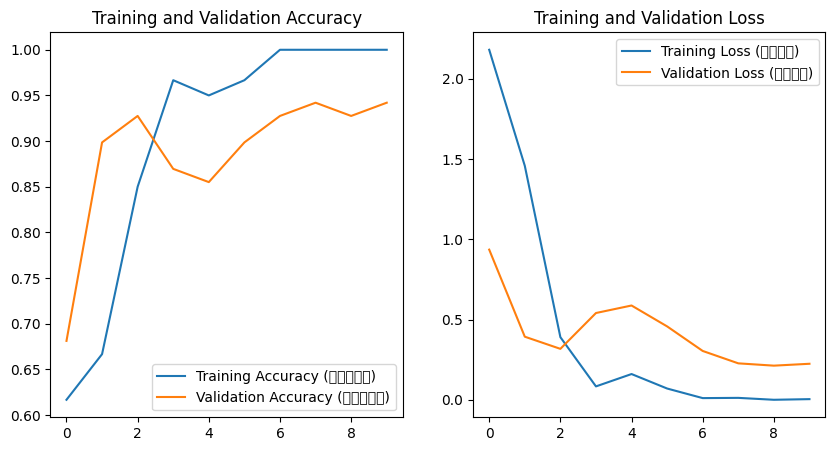

In [ ]:
# 提取訓練過程中的準確率和損失值
acc = history.history['accuracy']
val_acc = history.history['val_accuracy'] # Corrected key
loss = history.history['loss']
val_loss = history.history['val_loss'] # Corrected key

epochs_range = range(EPOCHS)

# --- 1. 畫出準確率 (Accuracy) ---
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy (訓練準確率)')
plt.plot(epochs_range, val_acc, label='Validation Accuracy (驗證準確率)')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# --- 2. 畫出損失值 (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss (訓練損失)')
plt.plot(epochs_range, val_loss, label='Validation Loss (驗證損失)')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

# 顯示圖表
plt.show()

In [ ]:
# Install a Chinese font
!apt-get -qq update
!apt-get -qq install fonts-wqy-zenhei

In [ ]:
# Configure matplotlib to use the Chinese font
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Add the font to matplotlib's font manager
fm.fontManager.addfont('/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc')

# Set the font for all plots
plt.rcParams['font.family'] = 'wqy-zenhei'
plt.rcParams['axes.unicode_minus'] = False # Allow minus signs to be displayed correctly

After running the above cells, please re-run the plotting cell to see the Chinese characters displayed correctly.

In [ ]:
# --- 1. 隨便找一張測試圖片 ---
# 提醒：請確保你的 test/dog 路徑下真的有圖片
try:
    test_image_path = os.path.join("/content/drive/MyDrive/data/test/36.jpg")

    # --- 2. 載入並預處理圖片 ---
    img = load_img(test_image_path, target_size=(IMG_SIZE, IMG_SIZE)) # 載入並縮放
    img_array = img_to_array(img) # 轉成數字陣列
    img_array = np.expand_dims(img_array, axis=0) # 增加一個 "batch" 維度 (模型要求)
    img_array = preprocess_input(img_array) # VGG16 預處理

    # --- 3. 進行預測 ---
    prediction = model.predict(img_array)
    score = prediction[0][0] # 取得機率值

    # --- 4. 解讀結果 ---
    print(f"\n--- 預測 {test_image_path} ---")
    print(f"原始分數: {score}")

    if score > 0.5:
        # 假設 'dog' 是 1, 'cat' 是 0 (可以看上面 class_names 的順序)
        print(f"模型預測: {class_names[1]} (狗)")
    else:
        print(f"模型預測: {class_names[0]} (貓)")

except FileNotFoundError:
    print("\n(可選) 預測步驟失敗：找不到測試圖片。")
except Exception as e:
    print(f"\n(可選) 預測步驟出錯: {e}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

--- 預測 /content/drive/MyDrive/data/test/36.jpg ---
原始分數: 0.0741545781493187
模型預測: cat (貓)


In [ ]:

test_dir = "/content/drive/MyDrive/data/test" # 你的測試集根目錄
import glob
test_image_paths = glob.glob(os.path.join(test_dir, "*.jpg"))
if not test_image_paths:
    print(f"警告：在 {test_dir} 中找不到任何 .jpg 圖片檔案。請檢查路徑和副檔名。")
else:
    print(f"找到 {len(test_image_paths)} 張測試圖片，開始批量預測...")
    results = {}
    for i, test_image_path in enumerate(test_image_paths):
        try:
            # 載入並縮放圖片
            img = load_img(test_image_path, target_size=(IMG_SIZE, IMG_SIZE))
            img_array = img_to_array(img) # 轉成數字陣列
            img_array = np.expand_dims(img_array, axis=0) # 增加 batch 維度
            img_array = preprocess_input(img_array) # VGG16 預處理
            prediction = model.predict(img_array, verbose=0) # verbose=0 讓輸出更乾淨
            score = prediction[0][0] # 取得機率值

            predicted_class_index = 1 if score > 0.5 else 0
            predicted_label = class_names[predicted_class_index]
            confidence = score if predicted_class_index == 1 else (1 - score)

            # 儲存結果
            results[os.path.basename(test_image_path)] = {
                'prediction': predicted_label,
                'confidence': float(confidence)
            }
            # 打印進度 (每 50 張打印一次)
            if (i + 1) % 50 == 0:
                print(f"已處理 {i + 1} / {len(test_image_paths)} 張圖片...")

        except Exception as e:
            results[os.path.basename(test_image_path)] = {
                'prediction': 'Error',
                'confidence': 0.0,
                'message': str(e)
            }
            # print(f"處理圖片 {test_image_path} 時發生錯誤: {e}")

    # --- 3. 輸出所有結果 ---
    print("\n--- 所有測試集圖片預測結果 ---")
    dog_count = 0
    cat_count = 0
    for filename, res in results.items():
        if res['prediction'] == class_names[1]:
            dog_count += 1
            print(f"檔案: {filename} -> 預測: {res['prediction']} (機率: {res['confidence']:.4f})")
        elif res['prediction'] == class_names[0]:
            cat_count += 1
            print(f"檔案: {filename} -> 預測: {res['prediction']} (機率: {res['confidence']:.4f})")
        else:
            print(f"檔案: {filename} -> 錯誤: {res['message']}")
    print("-" * 30)
    print(f"總計 {len(test_image_paths)} 張圖片： 貓 (Cat) 數量: {cat_count}, 狗 (Dog) 數量: {dog_count}")

找到 12 張測試圖片，開始批量預測...

--- 所有測試集圖片預測結果 ---
檔案: 1.jpg -> 預測: dog (機率: 1.0000)
檔案: 17.jpg -> 預測: dog (機率: 0.5297)
檔案: 18.jpg -> 預測: dog (機率: 1.0000)
檔案: 19.jpg -> 預測: cat (機率: 1.0000)
檔案: 20.jpg -> 預測: dog (機率: 0.7739)
檔案: 2.jpg -> 預測: dog (機率: 1.0000)
檔案: 3.jpg -> 預測: dog (機率: 1.0000)
檔案: 33.jpg -> 預測: dog (機率: 1.0000)
檔案: 34.jpg -> 預測: cat (機率: 1.0000)
檔案: 35.jpg -> 預測: cat (機率: 0.8388)
檔案: 36.jpg -> 預測: cat (機率: 0.9258)
檔案: 4.jpg -> 預測: dog (機率: 1.0000)
------------------------------
總計 12 張圖片： 貓 (Cat) 數量: 4, 狗 (Dog) 數量: 8
批量預測完成！
